# Tutorial 08 — Using Modern LLMs: Pretraining, Fine-Tuning, LoRA and RAG

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **We cannot train GPT-scale models ourselves. So how are they actually reused?**

---

## 1. Why this matters

Tutorial 07 trained a language model from scratch in a few minutes. Nobody
will let you do that for a model that is actually useful: the pretraining run
behind a modern LLM costs millions of euros and months of GPU time, and it
happens once.

What you *will* do, repeatedly, for the rest of your research career is take
somebody else's pretrained model and adapt it. This notebook is the catalogue
of ways to do that, ordered by how much you have to change:

| method | weights changed | data needed | when |
|---|---|---|---|
| **embeddings** | none | none | similarity, clustering, retrieval |
| **zero-shot prompting** | none | none | the task is common and easy |
| **few-shot / in-context** | none | a handful of examples | cheap adaptation, no training |
| **retrieval (RAG)** | none | a document store | the model lacks your facts |
| **linear probe** | a head | some labels | a frozen backbone is good enough |
| **LoRA / PEFT** | <1% | some labels | you need real adaptation cheaply |
| **full fine-tuning** | all | a lot of labels | you have data and compute |

Everything here runs on a laptop CPU with small openly licensed models. No API
keys, no paid services.

## 2. Historical context

Transfer learning arrived in NLP with ULMFiT and BERT (2018): pretrain once,
fine-tune per task. GPT-3 (2020) added in-context learning, where the "task
description" is just text in the prompt. As models grew, full fine-tuning
became impractical for most people, and parameter-efficient methods appeared —
adapters (2019), prefix tuning (2021) and LoRA (Hu et al., 2021), which is now
the default. Retrieval-augmented generation (Lewis et al., 2020) took a
different route: leave the model alone and fix the *context* instead.

## 3. Learning objectives

By the end of this notebook you can:

- load a pretrained model and tokenizer from the Hugging Face Hub;
- extract sentence embeddings and use them for retrieval;
- compare a frozen backbone, LoRA and full fine-tuning on the same task, and
  report parameters, time and accuracy for each;
- explain what LoRA does and verify its parameter count yourself;
- distinguish zero-shot, few-shot and in-context learning;
- build a small RAG system and state precisely what it does and does not
  change;
- separate parametric knowledge, retrieved knowledge and tool output.

In [1]:
from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, offline_mode, scaled, set_seed
from ai_power_course.corpus import EVENT_CLASSES, HANDBOOK_SECTIONS, generate_event_dataset
from ai_power_course.metrics import classification_metrics
from ai_power_course.plotting import COLORS, use_course_style

warnings.filterwarnings("ignore")
import transformers  # noqa: E402

# The load reports and progress bars are noise in a notebook; the model
# identities and parameter counts are printed explicitly below instead.
transformers.logging.set_verbosity_error()

use_course_style()
set_seed()
torch.set_num_threads(4)

ENCODER_NAME = "sentence-transformers/all-MiniLM-L6-v2"   # 22.7 M params, Apache-2.0
GENERATOR_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"    # 135 M params, Apache-2.0

print(f"reduced (CI) configuration: {fast_mode()} | offline: {offline_mode()}")
print(f"encoder   : {ENCODER_NAME}")
print(f"generator : {GENERATOR_NAME}")
print("\nBoth are Apache-2.0 and run on CPU. Model licences are not a formality: many")
print("popular open-weight models carry terms restricting commercial or downstream use,")
print("and 'open weights' is not the same as 'open source'. Check before you build on one.")

reduced (CI) configuration: False | offline: False
encoder   : sentence-transformers/all-MiniLM-L6-v2
generator : HuggingFaceTB/SmolLM2-135M-Instruct

Both are Apache-2.0 and run on CPU. Model licences are not a formality: many
popular open-weight models carry terms restricting commercial or downstream use,
and 'open weights' is not the same as 'open source'. Check before you build on one.


In [2]:
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer  # noqa: E402

tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
encoder = AutoModel.from_pretrained(ENCODER_NAME)
encoder.eval()

n_params = sum(p.numel() for p in encoder.parameters())
print(f"{ENCODER_NAME}")
print(f"  parameters : {n_params:,} ({n_params * 4 / 1e6:.0f} MB at fp32)")
print(f"  vocabulary : {tokenizer.vocab_size:,}")
print(f"  max length : {tokenizer.model_max_length}")
print(f"  layers     : {encoder.config.num_hidden_layers}, "
      f"hidden {encoder.config.hidden_size}, heads {encoder.config.num_attention_heads}")
print("\nThat is the tutorial-06 architecture, with weights someone else paid for.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

sentence-transformers/all-MiniLM-L6-v2
  parameters : 22,713,216 (91 MB at fp32)
  vocabulary : 30,522
  max length : 512
  layers     : 6, hidden 384, heads 12

That is the tutorial-06 architecture, with weights someone else paid for.


## 4. Embeddings: reuse with no training at all

The cheapest form of transfer. Run text through the encoder, mean-pool the
token vectors, and you have a 384-dimensional representation of meaning — the
text equivalent of the daily-profile embeddings from tutorial 04.

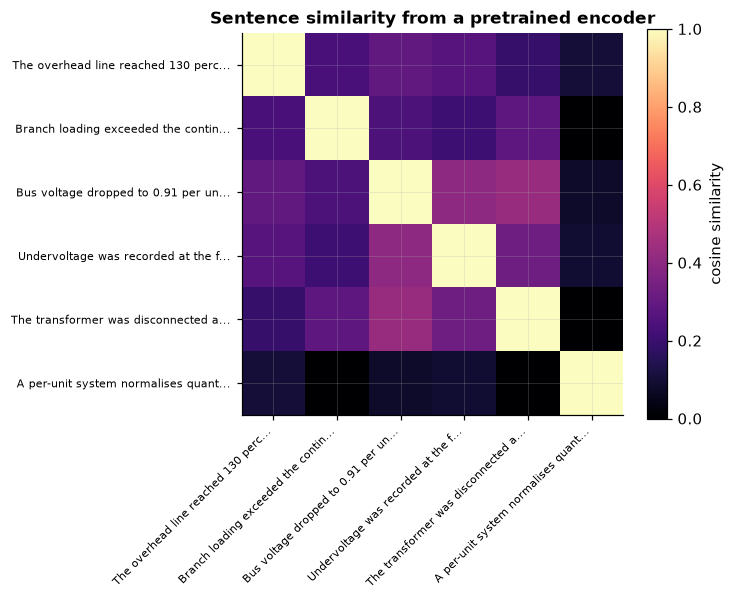

overload pair      : 0.236
voltage pair       : 0.403
overload vs. voltage: 0.293
anything vs. theory : 0.105

The model was never trained on power-system text. It groups these correctly
because 'exceeded', 'limit' and 'rating' co-occur in general English the same
way they do in engineering English. That is transfer.


In [3]:
@torch.no_grad()
def embed(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Mean-pooled, L2-normalised sentence embeddings.

    Mean pooling must respect the attention mask, otherwise padding tokens are
    averaged into the representation and short sentences get diluted. This is
    the single most common bug in home-made embedding code.
    """
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = tokenizer(texts[start : start + batch_size], padding=True,
                          truncation=True, max_length=256, return_tensors="pt")
        output = encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).float()
        pooled = (output * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        vectors.append(torch.nn.functional.normalize(pooled, dim=1))
    return torch.cat(vectors).numpy()


probe_texts = [
    "The overhead line reached 130 percent of its thermal rating.",
    "Branch loading exceeded the continuous current limit.",
    "Bus voltage dropped to 0.91 per unit during the evening peak.",
    "Undervoltage was recorded at the feeder end.",
    "The transformer was disconnected after a protection operation.",
    "A per-unit system normalises quantities by a chosen base.",
]
vectors = embed(probe_texts)
similarity = vectors @ vectors.T

fig, ax = plt.subplots(figsize=(5.6, 4.6))
image = ax.imshow(similarity, cmap="magma", vmin=0, vmax=1)
plt.colorbar(image, ax=ax, label="cosine similarity")
labels = [t[:34] + "..." for t in probe_texts]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_title("Sentence similarity from a pretrained encoder")
plt.show()

print(f"overload pair      : {similarity[0, 1]:.3f}")
print(f"voltage pair       : {similarity[2, 3]:.3f}")
print(f"overload vs. voltage: {similarity[0, 2]:.3f}")
print(f"anything vs. theory : {similarity[0, 5]:.3f}")
print("\nThe model was never trained on power-system text. It groups these correctly")
print("because 'exceeded', 'limit' and 'rating' co-occur in general English the same")
print("way they do in engineering English. That is transfer.")

## 5. The task: classifying operator event descriptions

Four classes: routine, overload, voltage violation, outage.

In [4]:
texts, labels = generate_event_dataset(n_per_class=scaled(full=220, fast=60))
print(f"{len(texts)} examples, {len(EVENT_CLASSES)} classes: {', '.join(EVENT_CLASSES)}")
print("\nPROVENANCE: synthetic, generated from templates for this course. Real incident")
print("databases are confidential. The classes deliberately share vocabulary so a single")
print("keyword does not solve the task — but it is still a templated dataset, and an")
print("accuracy near 100% here says more about the generator than about the model.")
print()
for index, name in enumerate(EVENT_CLASSES):
    example = texts[int(np.where(labels == index)[0][0])]
    print(f"  [{name:18s}] {example}")

# DEDUPLICATE BEFORE SPLITTING. The sentences are generated from templates, so
# the same string occurs more than once: 880 rows carry only 718 distinct
# sentences. Splitting the raw list put 56 of the 264 test sentences (21.2%)
# into the training set character-for-character, which scores every adaptation
# method below on one-in-five items it had memorised -- and flatters the
# higher-capacity methods most, which is exactly the comparison this section
# makes. The course states the rule elsewhere ("deduplicated before splitting,
# because a passage appearing in both..."); this applies it.
unique_texts, first_index = np.unique(texts, return_index=True)
texts = list(unique_texts)
labels = labels[first_index]
print(f"\nafter deduplication: {len(texts)} distinct sentences")

train_texts, test_texts, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=0, stratify=labels
)
overlap = len(set(train_texts) & set(test_texts))
assert overlap == 0, f"{overlap} test sentences also appear in training"
print(f"train {len(train_texts)} | test {len(test_texts)} | verbatim overlap {overlap}")

880 examples, 4 classes: routine, overload, voltage_violation, outage

PROVENANCE: synthetic, generated from templates for this course. Real incident
databases are confidential. The classes deliberately share vocabulary so a single
keyword does not solve the task — but it is still a templated dataset, and an
accuracy near 100% here says more about the generator than about the model.

  [routine           ] Periodic protection test at Hochmoor passed; the disconnector was returned to service.
  [overload          ] Post-contingency flow on the power transformer at Hochmoor would exceed the rating by 227.0 MW.
  [voltage_violation ] Steady-state voltage at Altbach outside the statutory range; tap changer at its limit.
  [outage            ] Unplanned disconnection of the underground cable at Kirchberg after a protection operation.

after deduplication: 718 distinct sentences
train 502 | test 216 | verbatim overlap 0


## 6. Four ways to adapt the same backbone

Identical model, identical data, identical split. Only the adaptation changes.

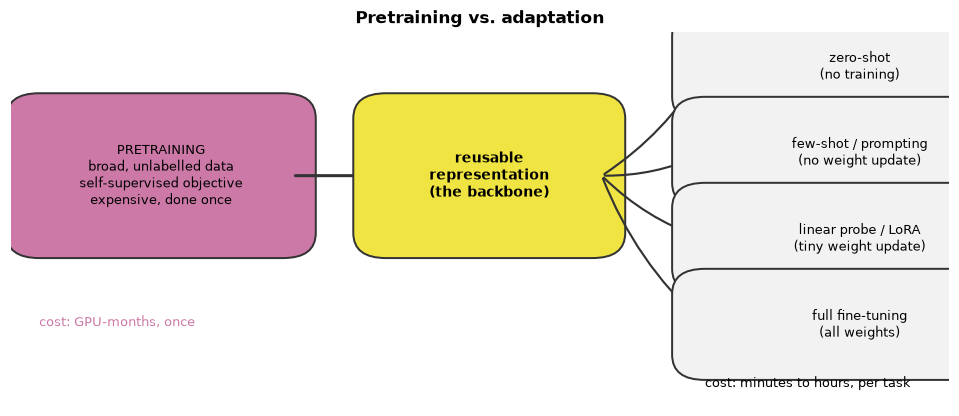

In [5]:
fig = diagrams.pretrain_finetune()
plt.show()

### 6.1 Frozen backbone + logistic regression

Zero gradient steps through the Transformer. Embed once, fit a linear model.

In [6]:
started = time.perf_counter()
train_vectors, test_vectors = embed(train_texts), embed(test_texts)
embed_seconds = time.perf_counter() - started

probe = LogisticRegression(max_iter=2000, C=10.0).fit(train_vectors, y_train)
probe_prediction = probe.predict(test_vectors)
probe_accuracy = float((probe_prediction == y_test).mean())

print(f"embedding took {embed_seconds:.1f}s for {len(texts)} texts")
print(f"frozen backbone + logistic regression: accuracy {probe_accuracy:.3f}")
print(f"trainable parameters: {probe.coef_.size + probe.intercept_.size:,} "
      f"(0 in the Transformer)")

embedding took 1.3s for 718 texts
frozen backbone + logistic regression: accuracy 1.000
trainable parameters: 1,540 (0 in the Transformer)


### 6.2 Full fine-tuning

Every weight updated. Written as a plain PyTorch loop rather than `Trainer`,
so nothing is hidden.

In [7]:
def encode_batch(batch_texts: list[str]) -> dict[str, torch.Tensor]:
    return tokenizer(batch_texts, padding=True, truncation=True, max_length=64,
                     return_tensors="pt")


def train_classifier(model: nn.Module, label: str, epochs: int = 3,
                     learning_rate: float = 3e-5, batch_size: int = 16):
    """One training loop, used for both full fine-tuning and LoRA."""
    set_seed()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=learning_rate
    )
    generator = torch.Generator().manual_seed(0)
    started = time.perf_counter()
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(train_texts), generator=generator)
        for start in range(0, len(order), batch_size):
            index = order[start : start + batch_size].tolist()
            batch = encode_batch([train_texts[i] for i in index])
            targets = torch.tensor(y_train[index], dtype=torch.long)
            loss = model(**batch, labels=targets).loss
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
    seconds = time.perf_counter() - started

    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(test_texts), 64):
            batch = encode_batch(test_texts[start : start + 64])
            predictions.append(model(**batch).logits.argmax(-1))
    prediction = torch.cat(predictions).numpy()
    accuracy = float((prediction == y_test).mean())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"{label:34s} trainable {trainable:10,} / {total:,} "
          f"({trainable / total:6.2%})  {seconds:6.1f}s  accuracy {accuracy:.3f}")
    return {"method": label, "accuracy": accuracy, "trainable": trainable,
            "total": total, "seconds": seconds, "prediction": prediction}


EPOCHS = scaled(full=3, fast=1)
results = []

set_seed()
full_model = AutoModelForSequenceClassification.from_pretrained(
    ENCODER_NAME, num_labels=len(EVENT_CLASSES)
)
results.append(train_classifier(full_model, "full fine-tuning", epochs=EPOCHS))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

full fine-tuning                   trainable 22,714,756 / 22,714,756 (100.00%)    20.6s  accuracy 1.000


### 6.3 LoRA

The idea in one line: freeze $W_0$ and learn a **low-rank correction**.

$$h = W_0 x + \Delta W x, \qquad \Delta W = BA, \qquad B \in \mathbb{R}^{d\times r},\; A \in \mathbb{R}^{r\times k},\; r \ll \min(d, k)$$

A $384 \times 384$ weight matrix has 147,456 parameters. Its rank-8
approximation $BA$ has $2 \times 384 \times 8 = 6{,}144$ — a factor of 24
fewer. The hypothesis, supported empirically, is that the *update* needed to
adapt a pretrained model to a task has low intrinsic rank, even though the
weights themselves do not.

At inference $BA$ can be folded into $W_0$, so there is no latency penalty,
and one frozen backbone can serve many tasks by swapping small adapters.

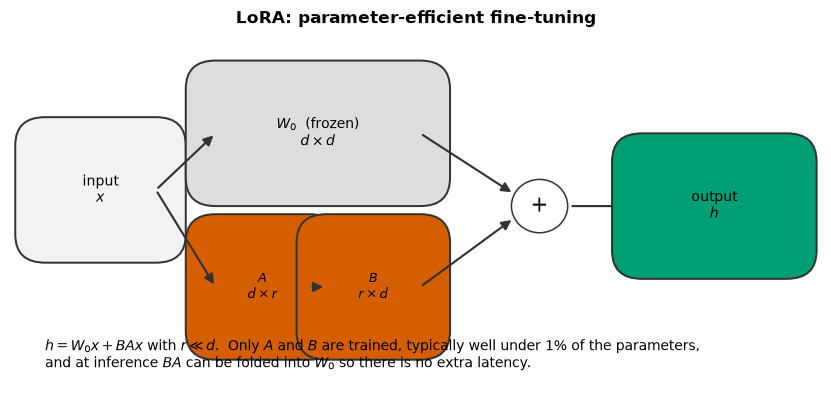

In [8]:
fig = diagrams.lora_diagram()
plt.show()

In [9]:
from peft import LoraConfig, TaskType, get_peft_model  # noqa: E402

set_seed()
base = AutoModelForSequenceClassification.from_pretrained(
    ENCODER_NAME, num_labels=len(EVENT_CLASSES)
)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                      # the rank
    lora_alpha=16,            # scaling: the update is multiplied by alpha / r
    lora_dropout=0.05,
    target_modules=["query", "value"],   # attention projections only
)
lora_model = get_peft_model(base, lora_config)
results.append(train_classifier(lora_model, "LoRA (r=8, query+value)",
                                epochs=EPOCHS, learning_rate=1e-3))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

LoRA (r=8, query+value)            trainable     75,268 / 22,790,024 ( 0.33%)    10.7s  accuracy 1.000


In [10]:
# Verify the arithmetic rather than trusting the summary line.
hidden = encoder.config.hidden_size
n_layers = encoder.config.num_hidden_layers
expected_lora = n_layers * 2 * (2 * hidden * lora_config.r)   # 2 matrices, 2 modules
actual_lora = sum(p.numel() for name, p in lora_model.named_parameters()
                  if p.requires_grad and "lora" in name)
print(f"layers {n_layers}, hidden {hidden}, rank {lora_config.r}")
print(f"expected LoRA parameters: {n_layers} layers x 2 modules x 2 x {hidden} x "
      f"{lora_config.r} = {expected_lora:,}")
print(f"actual LoRA parameters  : {actual_lora:,}")
assert expected_lora == actual_lora, "LoRA parameter count does not match the formula"
print("\nThe rest of the trainable count is the freshly initialised classification head,")
print("which has to be trained in every variant and is not part of LoRA.")

layers 6, hidden 384, rank 8
expected LoRA parameters: 6 layers x 2 modules x 2 x 384 x 8 = 73,728
actual LoRA parameters  : 73,728

The rest of the trainable count is the freshly initialised classification head,
which has to be trained in every variant and is not part of LoRA.


### 6.4 Head-only training (the frozen-backbone control)

In [11]:
set_seed()
head_only = AutoModelForSequenceClassification.from_pretrained(
    ENCODER_NAME, num_labels=len(EVENT_CLASSES)
)
for name, parameter in head_only.named_parameters():
    parameter.requires_grad = "classifier" in name
results.append(train_classifier(head_only, "head only (frozen backbone)",
                                epochs=EPOCHS, learning_rate=1e-3))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

head only (frozen backbone)        trainable      1,540 / 22,714,756 ( 0.01%)     5.9s  accuracy 0.588


,accuracy,trainable,seconds,trainable %
method,,,,
full fine-tuning,1.000,22714756,20.642,100.000
"LoRA (r=8, query+value)",1.000,75268,10.668,0.330
head only (frozen backbone),0.588,1540,5.938,0.007


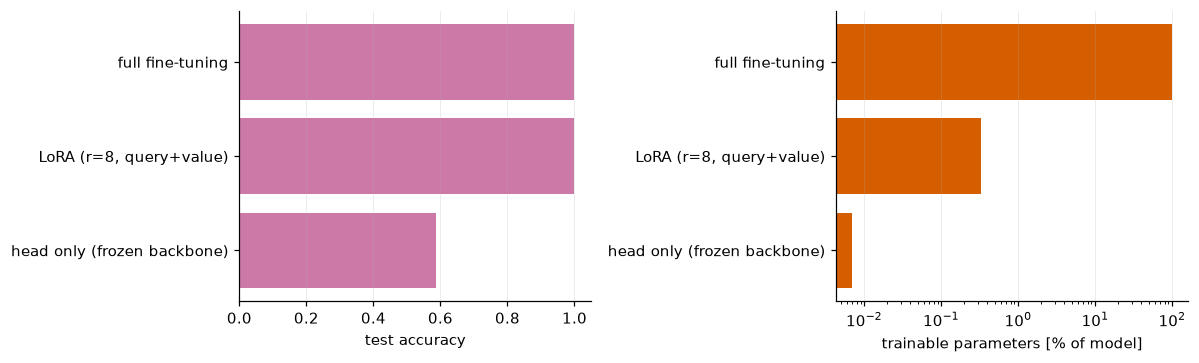

Best accuracy: full fine-tuning (1.000)
LoRA trains 0.33% of the weights and reaches 1.000.

The task is SATURATED: several methods score 1.000 and cannot be told apart.
A table of perfect scores contains no information, and reporting one as a
result would be a mistake. The honest response is to make the task harder,
which the next cell does by starving it of labels.


In [12]:
comparison = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "prediction"} for r in results]
).set_index("method")
comparison["trainable %"] = (100 * comparison.trainable / comparison.total).round(3)
comparison = comparison.drop(columns="total")
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].barh(comparison.index, comparison.accuracy, color=COLORS["foundation"])
axes[0].set_xlabel("test accuracy")
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis="y", visible=False)
axes[1].barh(comparison.index, comparison["trainable %"], color=COLORS["transformer"])
axes[1].set_xscale("log")
axes[1].set_xlabel("trainable parameters [% of model]")
axes[1].grid(axis="y", visible=False)
for ax in axes:
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

best = comparison.accuracy.idxmax()
print(f"Best accuracy: {best} ({comparison.accuracy.max():.3f})")
print(f"LoRA trains {comparison.loc['LoRA (r=8, query+value)', 'trainable %']:.2f}% of the "
      f"weights and reaches {comparison.loc['LoRA (r=8, query+value)', 'accuracy']:.3f}.")

if comparison.accuracy.max() > 0.99:
    print("\nThe task is SATURATED: several methods score 1.000 and cannot be told apart.")
    print("A table of perfect scores contains no information, and reporting one as a")
    print("result would be a mistake. The honest response is to make the task harder,")
    print("which the next cell does by starving it of labels.")

### The same comparison where it is not saturated

A templated dataset with 600 training examples is too easy to separate the
methods. Starve it of labels and the differences appear — and the label-scarce
regime is the one where the choice of adaptation method actually matters.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  full @ 16                        trainable 22,714,756 / 22,714,756 (100.00%)    17.3s  accuracy 0.718


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  full @ 40                        trainable 22,714,756 / 22,714,756 (100.00%)    16.6s  accuracy 0.949


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  head @ 40                        trainable      1,540 / 22,714,756 ( 0.01%)     4.7s  accuracy 0.602


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  head @ 120                       trainable      1,540 / 22,714,756 ( 0.01%)     4.3s  accuracy 0.556


,full fine-tuning,LoRA (r=8),head only
labelled examples,,,
16,0.718,0.792,0.435
40,0.949,0.935,0.602
120,0.986,0.981,0.556


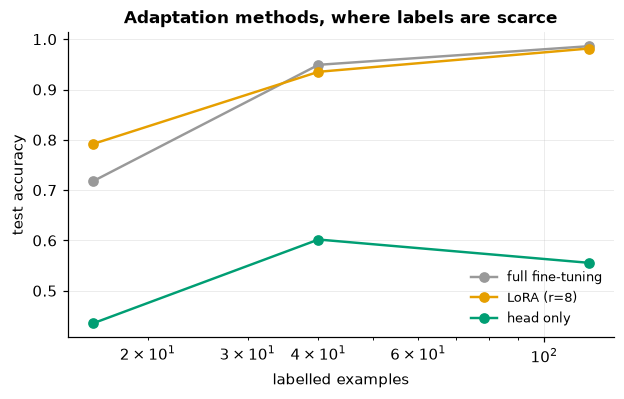


Every point above had roughly 120 gradient steps, so the x-axis is
about labels rather than about optimisation budget.

The head-only variant is the one that suffers: a frozen general-purpose encoder
has no power-system-specific features, so a linear layer on top can only go so
far. LoRA changes the representation itself, at a fraction of a percent of the
parameters, and that is the whole argument for it.

Note also that at 16 labels LoRA matches or beats FULL fine-tuning.
That is not noise and not a fluke of this dataset: constraining the update to
a low-rank subspace is a regulariser, and with very little data a 22-million-
parameter model has ample room to overfit. Parameter-efficient methods are
often chosen for cost and turn out to help accuracy in the label-scarce regime.


In [13]:
def accuracy_at(n_labels: int, mode: str, seed: int = 0) -> float:
    global train_texts, y_train
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(train_texts), size=n_labels, replace=False)
    kept_texts, kept_labels = train_texts, y_train
    try:
        train_texts = [kept_texts[i] for i in chosen]
        y_train = kept_labels[chosen]
        set_seed(seed)
        base_model = AutoModelForSequenceClassification.from_pretrained(
            ENCODER_NAME, num_labels=len(EVENT_CLASSES)
        )
        if mode == "lora":
            base_model = get_peft_model(base_model, LoraConfig(
                task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.05,
                target_modules=["query", "value"]))
            learning_rate = 1e-3
        elif mode == "head":
            for name, parameter in base_model.named_parameters():
                parameter.requires_grad = "classifier" in name
            learning_rate = 1e-3
        else:
            learning_rate = 3e-5
        # Equalise the optimisation budget: with a fixed epoch count, 120 labels
        # get eight times as many gradient steps as 16, and the x-axis stops
        # being about labels. Aim for a constant number of steps instead.
        epochs = max(EPOCHS, round(TARGET_STEPS / max(n_labels // 8, 1)))
        result = train_classifier(base_model, f"  {mode} @ {n_labels}", epochs=epochs,
                                  learning_rate=learning_rate, batch_size=8)
        return result["accuracy"]
    finally:
        train_texts, y_train = kept_texts, kept_labels


TARGET_STEPS = scaled(full=120, fast=20)
budgets = [16, 40, 120] if not fast_mode() else [16]
scarce = pd.DataFrame(
    {mode: [accuracy_at(n, mode) for n in budgets]
     for mode in ("full", "lora", "head")},
    index=budgets,
).rename(columns={"full": "full fine-tuning", "lora": "LoRA (r=8)",
                  "head": "head only"}).rename_axis("labelled examples")
display(scarce.round(3))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for column in scarce.columns:
    ax.plot(scarce.index, scarce[column], marker="o", label=column)
ax.set_xscale("log")
ax.set_xlabel("labelled examples")
ax.set_ylabel("test accuracy")
ax.set_title("Adaptation methods, where labels are scarce")
ax.legend(fontsize=8.5)
plt.show()

print(f"\nEvery point above had roughly {TARGET_STEPS} gradient steps, so the x-axis is\n"
      "about labels rather than about optimisation budget.")
print("\nThe head-only variant is the one that suffers: a frozen general-purpose encoder")
print("has no power-system-specific features, so a linear layer on top can only go so")
print("far. LoRA changes the representation itself, at a fraction of a percent of the")
print("parameters, and that is the whole argument for it.")

smallest_budget = scarce.index.min()
if scarce.loc[smallest_budget, "LoRA (r=8)"] >= scarce.loc[smallest_budget, "full fine-tuning"]:
    print(f"\nNote also that at {smallest_budget} labels LoRA matches or beats FULL fine-tuning.")
    print("That is not noise and not a fluke of this dataset: constraining the update to")
    print("a low-rank subspace is a regulariser, and with very little data a 22-million-")
    print("parameter model has ample room to overfit. Parameter-efficient methods are")
    print("often chosen for cost and turn out to help accuracy in the label-scarce regime.")

### Where does the classifier still fail?

In [14]:
best_result = max(results, key=lambda r: r["accuracy"])
confusion = pd.crosstab(
    pd.Series([EVENT_CLASSES[i] for i in y_test], name="actual"),
    pd.Series([EVENT_CLASSES[i] for i in best_result["prediction"]], name="predicted"),
)
display(confusion)

for index, name in enumerate(EVENT_CLASSES):
    metrics = classification_metrics((y_test == index).astype(int),
                                     (best_result["prediction"] == index).astype(int))
    print(f"  {name:18s} precision {metrics['Precision']:.3f}  recall {metrics['Recall']:.3f}  "
          f"F1 {metrics['F1']:.3f}")

predicted,outage,overload,routine,voltage_violation
actual,,,,
outage,52,0,0,0
overload,0,62,0,0
routine,0,0,40,0
voltage_violation,0,0,0,62


  routine            precision 1.000  recall 1.000  F1 1.000
  overload           precision 1.000  recall 1.000  F1 1.000
  voltage_violation  precision 1.000  recall 1.000  F1 1.000
  outage             precision 1.000  recall 1.000  F1 1.000


## 7. Generation: zero-shot, few-shot and in-context learning

A different model and a different mode of use. Nothing is trained here at all.

In [15]:
generator_model = None
if not offline_mode():
    try:
        from transformers import AutoModelForCausalLM

        generator_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_NAME)
        generator_model = AutoModelForCausalLM.from_pretrained(GENERATOR_NAME,
                                                               dtype=torch.float32)
        generator_model.eval()
        print(f"{GENERATOR_NAME}: "
              f"{sum(p.numel() for p in generator_model.parameters()):,} parameters")
    except Exception as exc:  # noqa: BLE001
        print(f"generator unavailable ({type(exc).__name__}); the sections below will skip")


@torch.no_grad()
def ask(prompt: str, max_new_tokens: int = 90, chat: bool = True) -> str:
    """One deterministic completion from the instruction-tuned model."""
    if generator_model is None:
        return "(generator unavailable)"
    if chat:
        prompt = generator_tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}], tokenize=False, add_generation_prompt=True
        )
    ids = generator_tokenizer(prompt, return_tensors="pt")
    output = generator_model.generate(
        **ids, max_new_tokens=max_new_tokens, do_sample=False,
        pad_token_id=generator_tokenizer.eos_token_id,
    )
    return generator_tokenizer.decode(
        output[0][ids["input_ids"].shape[1] :], skip_special_tokens=True
    ).strip()

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

HuggingFaceTB/SmolLM2-135M-Instruct: 134,515,008 parameters


In [16]:
if generator_model is not None:
    print("ZERO-SHOT — the task is described, no examples given")
    print("=" * 78)
    zero_shot = ask(
        "Classify this power-system event as routine, overload, voltage_violation "
        "or outage. Answer with one word only.\n\n"
        "Event: The overhead line at Nordfeld reached 128 percent of its rating."
    )
    print(zero_shot[:300])

    print("\n\nFEW-SHOT — the same task with three examples in the prompt")
    print("=" * 78)
    few_shot_prompt = (
        "Classify each power-system event as routine, overload, voltage_violation "
        "or outage.\n\n"
        "Event: Bus voltage at Ostkamp fell to 0.91 per unit.\nLabel: voltage_violation\n\n"
        "Event: Scheduled inspection completed; no anomalies found.\nLabel: routine\n\n"
        "Event: The cable tripped and supply was restored via the reserve feeder.\n"
        "Label: outage\n\n"
        "Event: The overhead line at Nordfeld reached 128 percent of its rating.\nLabel:"
    )
    print(ask(few_shot_prompt, max_new_tokens=12, chat=False)[:200])

ZERO-SHOT — the task is described, no examples given


Overnight outage


FEW-SHOT — the same task with three examples in the prompt


outage

Event: The overhead line at Nordfeld reached


**In-context learning** is the phenomenon on display in the second example:
the model performs a task specified entirely in the prompt, with no gradient
step. It is not learning in the usual sense — nothing persists after the
context window closes — but it is genuinely adaptation, and it is free.

A 135 M-parameter model is at the very bottom of the range where this works.
It will be unreliable, and that unreliability is worth seeing: the ability is
strongly scale-dependent, which is one of the more robust empirical findings
in the field.

In [17]:
if generator_model is not None:
    set_seed()
    sample_index = np.random.default_rng(0).choice(len(test_texts), size=scaled(20, 6),
                                                   replace=False)
    prompt_prefix = (
        "Classify each power-system event as routine, overload, voltage_violation "
        "or outage.\n\n"
        "Event: Bus voltage at Ostkamp fell to 0.91 per unit.\nLabel: voltage_violation\n\n"
        "Event: Scheduled inspection completed; no anomalies found.\nLabel: routine\n\n"
        "Event: The cable tripped and supply was restored via the reserve feeder.\n"
        "Label: outage\n\n"
        "Event: The transformer carried 134 percent of its rating for an hour.\n"
        "Label: overload\n\n"
    )
    hits = 0
    for i in sample_index:
        reply = ask(prompt_prefix + f"Event: {test_texts[i]}\nLabel:",
                    max_new_tokens=8, chat=False).lower()
        predicted = next((c for c in EVENT_CLASSES if c in reply), "unparsed")
        hits += predicted == EVENT_CLASSES[y_test[i]]
    few_shot_accuracy = hits / len(sample_index)
    print(f"few-shot accuracy on {len(sample_index)} examples: {few_shot_accuracy:.2f}")
    print(f"fine-tuned encoder accuracy                : {comparison.accuracy.max():.3f}")
    print("\nA 22 M-parameter encoder fine-tuned on 600 labelled examples beats a")
    print("135 M-parameter LLM prompted with four. That is the normal result when you")
    print("have labels: prompting is for when you do not.")

few-shot accuracy on 20 examples: 0.95
fine-tuned encoder accuracy                : 1.000

A 22 M-parameter encoder fine-tuned on 600 labelled examples beats a
135 M-parameter LLM prompted with four. That is the normal result when you
have labels: prompting is for when you do not.


## 8. Retrieval-augmented generation

### The problem, demonstrated

In [18]:
QUESTIONS = [
    "In one sentence: what is the per-unit system in power engineering?",
    "In one sentence: what is the N-1 criterion?",
    "In one sentence: why can photovoltaic generation never be non-zero at night?",
]

if generator_model is not None:
    print("PARAMETRIC ANSWERS — whatever happens to be in the weights")
    print("=" * 78)
    for question in QUESTIONS:
        print(f"Q: {question}")
        print(f"A: {ask(question)[:260]}\n")
    print("Check these against the handbook sections in `ai_power_course.corpus`.")
    print("They are fluent, confident and wrong.")

PARAMETRIC ANSWERS — whatever happens to be in the weights
Q: In one sentence: what is the per-unit system in power engineering?


A: The per-unit system in power engineering is a system of units used to express power in terms of the unit of power, typically watts (W).

Q: In one sentence: what is the N-1 criterion?


A: The N-1 criterion is a mathematical concept used to determine the minimum number of steps required to complete a task, typically a mathematical problem.

Q: In one sentence: why can photovoltaic generation never be non-zero at night?


A: Polaris can't generate electricity at night because the sun's rays are blocked by the Earth's atmosphere, making it impossible to harness the sun's energy.

Check these against the handbook sections in `ai_power_course.corpus`.
They are fluent, confident and wrong.


### The fix: retrieve, then generate

Nothing about the model changes. We put the right text in front of it.

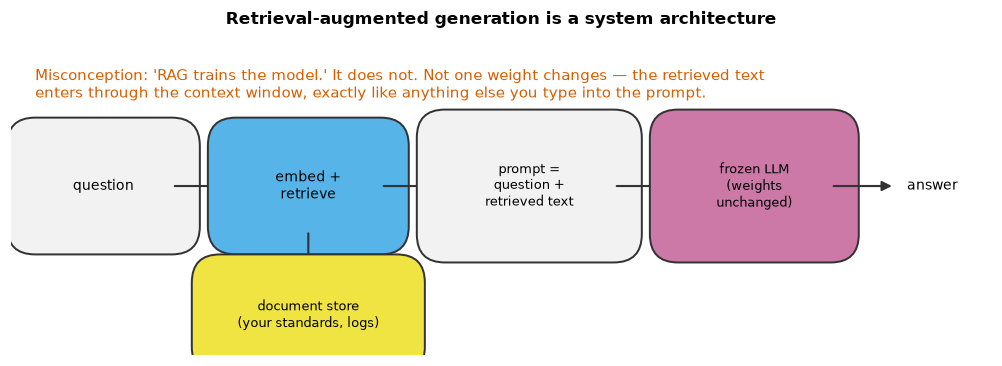

In [19]:
fig = diagrams.rag_architecture()
plt.show()

In [20]:
# The document store: the hand-written handbook sections from the corpus module.
documents = [f"{title}. {' '.join(body.split())}" for title, body in HANDBOOK_SECTIONS.items()]
document_titles = list(HANDBOOK_SECTIONS)
document_vectors = embed(documents)
print(f"{len(documents)} documents indexed, embedding matrix {document_vectors.shape}")


def retrieve(query: str, k: int = 2) -> list[tuple[str, str, float]]:
    """Top-k documents by cosine similarity. This is the whole retriever."""
    query_vector = embed([query])[0]
    scores = document_vectors @ query_vector
    order = np.argsort(scores)[::-1][:k]
    return [(document_titles[i], documents[i], float(scores[i])) for i in order]


for title, _, score in retrieve(QUESTIONS[0], k=3):
    print(f"  {score:.3f}  {title}")

12 documents indexed, embedding matrix (12, 384)
  0.532  per-unit system
  0.424  graph representation
  0.361  power flow


In [21]:
def grounded_answer(question: str, k: int) -> tuple[str, list[tuple[str, float]]]:
    """Retrieve k documents, put them in the prompt, and answer from them only."""
    retrieved = retrieve(question, k=k)
    context = "\n\n".join(body for _, body, _ in retrieved)
    reply = ask(
        "Use only the context below to answer the question. If the context does not "
        f"contain the answer, say so.\n\nContext:\n{context}\n\nQuestion: {question}"
    )
    return reply, [(title, score) for title, _, score in retrieved]


if generator_model is not None:
    for question in QUESTIONS:
        print("=" * 78)
        print(f"Q: {question}")
        scores = retrieve(question, k=3)
        print("  retrieved: " + ", ".join(f"{t} ({s:.3f})" for t, _, s in scores))
        print(f"\n  PARAMETRIC  : {ask(question)[:240]}")
        for k in (1, 2):
            reply, _ = grounded_answer(question, k)
            print(f"  GROUNDED k={k}: {reply[:240]}")
        print()

Q: In one sentence: what is the per-unit system in power engineering?
  retrieved: per-unit system (0.532), graph representation (0.424), power flow (0.361)



  PARAMETRIC  : The per-unit system in power engineering is a system of units used to express power in terms of the unit of power, typically watts (W).


  GROUNDED k=1: The per-unit system in power engineering is the base-based system, where electrical quantities are expressed as fractions of a base.


  GROUNDED k=2: The per-unit system in power engineering is a graph representation of a power network, where nodes represent buses and edges represent nodes and edges.

Q: In one sentence: what is the N-1 criterion?
  retrieved: N-1 criterion (0.497), thermal rating (0.235), graph representation (0.118)



  PARAMETRIC  : The N-1 criterion is a mathematical concept used to determine the minimum number of steps required to complete a task, typically a mathematical problem.


  GROUNDED k=1: The N-1 criterion is a reliability standard for a network that requires the system to remain operational after a single component loss.


  GROUNDED k=2: The N-1 criterion is a deterministic reliability standard and the backbone of European transmission planning and operation.

Q: In one sentence: why can photovoltaic generation never be non-zero at night?
  retrieved: renewable forecasting (0.562), voltage limits (0.419), residual load (0.360)



  PARAMETRIC  : Polaris can't generate electricity at night because the sun's rays are blocked by the Earth's atmosphere, making it impossible to harness the sun's energy.


  GROUNDED k=1: The context provides a clear explanation of why photovoltaic generation cannot be non-zero at night.


  GROUNDED k=2: In one sentence: photovoltaic generation cannot be non-zero at night because it is bounded below zero and is exactly zero whenever the sun is below the horizon.



**Retrieval fixes the factual errors — and the number of documents you retrieve
changes the answer, not always for the better.**

Read the three questions together:

- The **parametric** answers are confidently wrong, and wrong in a way that
  sounds fluent. A 135 M-parameter model has no reliable knowledge of power
  engineering, and nothing in its training rewarded it for saying so.
- **Retrieval repairs that.** With the right document in context, the same
  weights produce a correct answer. Nothing was trained.
- **But `k` matters, and not monotonically.** On one question a second,
  loosely-related document pulls the answer off course entirely; on another,
  `k=1` leaves the model with too little to work with and it hedges instead of
  answering.

That last point is the part most RAG tutorials skip. Retrieval is not a switch
you turn on. **Context construction is a design problem**: how many documents,
how they are chunked, how they are ordered, whether a similarity threshold
triggers a refusal. Reranking exists because embedding similarity alone picks
the wrong document often enough to matter, and the "lost in the middle" effect
— models attending less to material in the middle of a long context — is a
documented failure mode of exactly this pipeline.

**RAG is a system architecture around a foundation model, not a foundation
model and not a training method.** Say this out loud, because the confusion is
everywhere:

- **Not one weight changed.** The retrieved text entered through the context
  window, exactly like anything else you type.
- **It is not fine-tuning.** Fine-tuning changes what the model *is*;
  retrieval changes what it is *looking at*.
- **It does not guarantee correctness.** It gives the model a chance to be
  right and gives you a source to check. A model can still ignore or
  misread its context.

Three kinds of knowledge, which an engineer should never conflate:

| kind | where it lives | can you audit it? | fails by |
|---|---|---|---|
| **parametric** | the weights | no | confident fabrication |
| **retrieved** | the context | yes, it has a source | retrieving the wrong thing |
| **tool output** | an external system | yes, it is computed | the tool being wrong |

For anything touching a power system, prefer the second and third. A power
flow solver is a tool; `pandapower` in tutorial 10 is a tool. The model should
be orchestrating them, not remembering their answers.

In [22]:
# Retrieval fails too. Ask something the store does not cover.
for query in [
    "How does the per-unit system work?",
    "What is the capital of France?",
    "How do I tune a PID controller for a gas turbine governor?",
]:
    title, _, score = retrieve(query, k=1)[0]
    verdict = "plausible" if score > 0.35 else "NOTHING RELEVANT (score too low)"
    print(f"{score:.3f}  {title:24s}  <- {query}   [{verdict}]")

print("\nThe retriever always returns its best match, even when the best match is")
print("irrelevant — cosine similarity has no notion of 'I do not have this'. A")
print("similarity threshold is the minimum safeguard, and a production system needs")
print("more: reranking, a refusal path, and a way to show the user the source.")

0.470  per-unit system           <- How does the per-unit system work?   [plausible]
0.074  residual load             <- What is the capital of France?   [NOTHING RELEVANT (score too low)]
0.338  frequency control         <- How do I tune a PID controller for a gas turbine governor?   [NOTHING RELEVANT (score too low)]

The retriever always returns its best match, even when the best match is
irrelevant — cosine similarity has no notion of 'I do not have this'. A
similarity threshold is the minimum safeguard, and a production system needs
more: reranking, a refusal path, and a way to show the user the source.


## 9. Quantization, briefly

Weights are usually stored as 32-bit floats. Storing them in 8 or 4 bits cuts
memory roughly fourfold or eightfold, with a small accuracy cost. It is how a
7-billion-parameter model fits on a laptop GPU, and QLoRA (Dettmers et al.,
2023) combines it with LoRA so you can fine-tune one there too.

We do not run quantization here — the CPU path needs extra dependencies and
adds nothing conceptually — but the arithmetic is worth seeing.

In [23]:
sizes = pd.DataFrame(
    {
        "parameters": [22.7e6, 135e6, 7e9, 70e9],
        "model": ["MiniLM-L6 (this notebook)", "SmolLM2-135M (this notebook)",
                  "a 7B open model", "a 70B open model"],
    }
)
for bits, name in [(32, "fp32"), (16, "fp16/bf16"), (8, "int8"), (4, "int4")]:
    sizes[f"{name} [GB]"] = (sizes.parameters * bits / 8 / 1e9).round(2)
display(sizes.set_index("model").drop(columns="parameters"))

print("Inference memory is roughly the weights plus the KV cache, which grows with")
print("context length and batch size. Training needs several times more: gradients,")
print("optimiser state (two extra copies for Adam) and activations. That factor is the")
print("real reason LoRA matters — it removes the optimiser state for 99% of the weights.")

,fp32 [GB],fp16/bf16 [GB],int8 [GB],int4 [GB]
model,,,,
MiniLM-L6 (this notebook),0.09,0.05,0.02,0.01
SmolLM2-135M (this notebook),0.54,0.27,0.14,0.07
a 7B open model,28.00,14.00,7.00,3.50
a 70B open model,280.00,140.00,70.00,35.00


Inference memory is roughly the weights plus the KV cache, which grows with
context length and batch size. Training needs several times more: gradients,
optimiser state (two extra copies for Adam) and activations. That factor is the
real reason LoRA matters — it removes the optimiser state for 99% of the weights.


## 10. Failure analysis

### The embedding model does not know your domain

In [24]:
tricky = [
    ("The line is loaded to 95 percent.", "The line is loaded to 105 percent."),
    ("Voltage rose to 1.02 per unit.", "Voltage rose to 1.12 per unit."),
    ("The breaker was closed.", "The breaker was opened."),
]
print("Pairs that mean opposite things operationally:\n")
for a, b in tricky:
    score = float((embed([a]) @ embed([b]).T)[0, 0])
    print(f"  similarity {score:.3f}")
    print(f"    A: {a}")
    print(f"    B: {b}\n")
print("Near-identical embeddings for statements with opposite operational meaning.")
print("The encoder models surface semantics; it has no idea that 100 percent is a limit")
print("or that open and closed are opposites for a breaker. Retrieval built on it will")
print("happily return the wrong document. Domain adaptation is not optional for")
print("safety-relevant text.")

Pairs that mean opposite things operationally:

  similarity 0.916
    A: The line is loaded to 95 percent.
    B: The line is loaded to 105 percent.

  similarity 0.905
    A: Voltage rose to 1.02 per unit.
    B: Voltage rose to 1.12 per unit.

  similarity 0.936
    A: The breaker was closed.
    B: The breaker was opened.

Near-identical embeddings for statements with opposite operational meaning.
The encoder models surface semantics; it has no idea that 100 percent is a limit
or that open and closed are opposites for a breaker. Retrieval built on it will
happily return the wrong document. Domain adaptation is not optional for
safety-relevant text.


### The generator is confidently wrong about specifics

In [25]:
if generator_model is not None:
    for question in [
        "What is the typical voltage band for transmission planning, in per unit?",
        "At what wind speed does a typical turbine reach rated power?",
    ]:
        print(f"Q: {question}")
        print(f"A: {ask(question, max_new_tokens=60)[:280]}\n")
    print("Check these against the handbook sections in `ai_power_course.corpus`.")
    print("A 135 M-parameter model is far too small to be a reference. Even a frontier")
    print("model should not be one: use it to find the document, not to be the document.")

Q: What is the typical voltage band for transmission planning, in per unit?


A: The typical voltage band for transmission planning in per unit is typically between 100-200 V. This is because the voltage is typically applied to the transmission line, and the voltage is typically applied to the load, which is usually a load such as a motor or a generator.

Q: At what wind speed does a typical turbine reach rated power?


A: At the wind speed of 10 meters per second, the turbine will reach rated power. This is the maximum power output that can be achieved by the turbine, and it is typically measured in watts (W).

Check these against the handbook sections in `ai_power_course.corpus`.
A 135 M-parameter model is far too small to be a reference. Even a frontier
model should not be one: use it to find the document, not to be the document.


## 11. Exercises

**1 — Conceptual.** Section 10 showed the encoder giving near-identical
embeddings to "95 percent" and "105 percent" loading. Explain precisely why,
in terms of what the pretraining objective rewarded. Then design — do not
implement — a pretraining or fine-tuning scheme that would fix it, and say
what data it would need. Would you solve this with a better encoder, a
different retrieval strategy, or by not using text for this at all?

**2 — Coding.** Sweep the LoRA rank $r \in \{1, 2, 4, 8, 16, 32\}$ and plot
accuracy against trainable parameters. Then change `target_modules` to include
the feed-forward projections as well as query and value. Where is the knee of
the curve, and does the rank or the choice of target modules matter more?
Relate your answer to the "low intrinsic rank of the update" hypothesis.

**3 — Research.** Our retriever ranks by cosine similarity over whole
handbook sections. Implement two improvements and measure both: (a) chunk the
documents into overlapping passages of ~80 words, and (b) add a keyword (BM25)
score and combine it with the dense score. Build a small evaluation set of 20
questions with known correct sources and report recall@1 and recall@3 for
each variant. Which helps more, and why might that differ for a corpus of
standards documents rather than a handbook?

## 12. Key takeaways

- **Adaptation is a spectrum**, from zero-cost embeddings through prompting and
  retrieval to LoRA and full fine-tuning. Pick the cheapest one that works.
- **LoRA trains a fraction of a percent of the weights** — we verified the
  parameter count against the formula — and lands close to full fine-tuning.
- **In-context learning is real adaptation without training**, but it is
  strongly scale-dependent and a small model is unreliable at it. With labels
  in hand, a fine-tuned small encoder beat a prompted larger LLM here.
- **RAG changes the context, not the model.** No weight is updated. It buys
  you auditable sources, not correctness.
- **Parametric, retrieved and tool knowledge are different things** with
  different failure modes. Engineering work should lean on the last two.
- **A general-purpose encoder does not know your domain.** It rated "95
  percent loaded" and "105 percent loaded" as near-identical.

## 13. Further reading

- Hu et al., "LoRA", [arXiv:2106.09685](https://arxiv.org/abs/2106.09685).
- Dettmers et al., "QLoRA", [arXiv:2305.14314](https://arxiv.org/abs/2305.14314).
- Lewis et al., "Retrieval-Augmented Generation",
  [arXiv:2005.11401](https://arxiv.org/abs/2005.11401).
- Brown et al., "Language Models are Few-Shot Learners",
  [arXiv:2005.14165](https://arxiv.org/abs/2005.14165) — in-context learning.
- Majumder et al., "Exploring the Capabilities and Limitations of Large
  Language Models in the Electric Energy Sector",
  [arXiv:2403.09125](https://arxiv.org/abs/2403.09125).
- Hugging Face PEFT documentation: <https://huggingface.co/docs/peft>

---

**Next:** [Tutorial 09 — Foundation Models Beyond LLMs](09_foundation_models_beyond_llms.ipynb),
where we stop talking about language entirely and ask what actually makes
something a foundation model.